# Specification Sensitivity: Comparing Four England NMF Models

Compares nmf_eng_5, nmf_eng_15, nmf_eng_30, and nmf_eng_30_nm to demonstrate how specification choices (topic count, source composition) shape AI outputs.

| Model | k | Corpus | Purpose |
|-------|---|--------|--------|
| nmf_eng_5 | 5 | Full | Source-proxy collapse demonstration |
| nmf_eng_15 | 15 | Full | Midpoint — where minority sources become audible |
| nmf_eng_30 | 30 | Full | Production model — full thematic resolution |
| nmf_eng_30_nm | 30 | No SchoolsWeek | Source composition sensitivity |


This level of specification analysis — training multiple model variants, comparing what changes, and showing that standard diagnostics can't detect the differences — is rarely done in deployed ML systems. Most pipelines stop at "does it fit the data well." AtlasED argues that a system which discloses its specification sensitivity is more trustworthy than one which hides it.


Top Five Contestability Findings
* Diagnostics are necessary but not sufficient — both k=30 models pass all evaluation checks identically yet produce different pictures of education policy.
* Source composition determines findings — removing one source (73% of corpus) changed ~2/3 of topics. "Topic discovery" is a function of who you scraped.
* k is a political choice, not a technical parameter — k=5 discovers sources, k=30 discovers policy themes. Both pass coherence checks. Standard metrics can't tell you which is "right."
* Dominant topic labels hide uncertainty — mean dominant weight of 0.13 means the label represents 13% of the article's content. The other 87% is invisible to the dashboard user.
* LLM evaluation has a structural blind spot — 28/30 naming agreement, but the LLM couldn't detect three near-duplicate topics. Per-topic validation cannot substitute for structural review.

# 0. Imports and Data

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Load all four model summaries
models = {}
for model_id in ["nmf_eng_5", "nmf_eng_15", "nmf_eng_30", "nmf_eng_30_nm"]:
    path = f"/workspaces/AM1_topic_modelling/data/evaluation_outputs/{model_id}_summary.json"
    try:
        with open(path) as f:
            models[model_id] = json.load(f)
        print(f"Loaded {model_id}: {models[model_id]['n_topics']} topics, {models[model_id]['n_articles']} articles")
    except FileNotFoundError:
        print(f"NOT FOUND: {path} — run the notebook first")

print(f"\nModels loaded: {len(models)}/4")

# Build master DataFrame — one row per topic per model
all_topics = []
for model_id, data in models.items():
    for t in data["topics"]:
        row = {**t}
        row["model_id"] = model_id
        row["k"] = data["n_topics"]
        row["n_articles"] = data["n_articles"]
        # Add model-level metrics to each row for easy access
        row["stability"] = data["metrics"]["stability"]
        row["recon_error"] = data["metrics"]["reconstruction_error"]
        row["mean_dominant_weight"] = data["metrics"]["mean_dominant_weight"]
        row["max_dominant_weight"] = data["metrics"]["max_dominant_weight"]
        all_topics.append(row)

df = pd.DataFrame(all_topics)
print(f"\nMaster DataFrame: {df.shape[0]} rows (topics across all models)")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded nmf_eng_5: 5 topics, 3943 articles
Loaded nmf_eng_15: 15 topics, 3943 articles
Loaded nmf_eng_30: 30 topics, 3943 articles
Loaded nmf_eng_30_nm: 30 topics, 1198 articles

Models loaded: 4/4

Master DataFrame: 80 rows (topics across all models)
Columns: ['topic_num', 'name', 'count', 'pct', 'top_source', 'top_source_pct', 'single_source', 'model_id', 'k', 'n_articles', 'stability', 'recon_error', 'mean_dominant_weight', 'max_dominant_weight']


,topic_num,name,count,pct,top_source,top_source_pct,single_source,model_id,k,n_articles,stability,recon_error,mean_dominant_weight,max_dominant_weight
0,0,pupil_welfare_and_inclusion,1943,49.3,schoolsweek,0.61,False,nmf_eng_5,5,3943,1.0,58.2615,0.0922,0.3029
1,1,academy_financial_oversight,160,4.1,gov,0.99,True,nmf_eng_5,5,3943,1.0,58.2615,0.0922,0.3029
2,2,academy_trust_governance,657,16.7,schoolsweek,0.79,False,nmf_eng_5,5,3943,1.0,58.2615,0.0922,0.3029
3,3,teacher_pay_and_workforce,798,20.2,schoolsweek,0.92,True,nmf_eng_5,5,3943,1.0,58.2615,0.0922,0.3029
4,4,ofsted_inspection_reform,385,9.8,schoolsweek,0.81,False,nmf_eng_5,5,3943,1.0,58.2615,0.0922,0.3029


In [2]:
df.columns

Index(['topic_num', 'name', 'count', 'pct', 'top_source', 'top_source_pct',
       'single_source', 'model_id', 'k', 'n_articles', 'stability',
       'recon_error', 'mean_dominant_weight', 'max_dominant_weight'],
      dtype='object')

## 1. Cross-k metrics comparison

In [3]:
# Cross-k metrics — one row per model from the DataFrame
metrics_df = df.groupby("model_id").agg(
    k=("k", "first"),
    articles=("n_articles", "first"),
    recon_error=("recon_error", "first"),
    stability=("stability", "first"),
    mean_weight=("mean_dominant_weight", "first"),
    max_weight=("max_dominant_weight", "first"),
    largest_topic_pct=("pct", "max"),
    smallest_topic_pct=("pct", "min"),
    single_source_count=("single_source", "sum"),
    total_topics=("topic_num", "count"),
).reset_index()

metrics_df["single_source_ratio"] = metrics_df["single_source_count"].astype(int).astype(str) + "/" + metrics_df["total_topics"].astype(str)

model_order = ["nmf_eng_5", "nmf_eng_15", "nmf_eng_30", "nmf_eng_30_nm"]
metrics_df = metrics_df.set_index("model_id").loc[model_order].reset_index()

metrics_df


,model_id,k,articles,recon_error,stability,mean_weight,max_weight,largest_topic_pct,smallest_topic_pct,single_source_count,total_topics,single_source_ratio
0,nmf_eng_5,5,3943,58.2615,1.0000,0.0922,0.3029,49.3,4.1,2,5,2/5
1,nmf_eng_15,15,3943,55.2926,1.0000,0.1216,0.3741,12.1,2.3,5,15,5/15
2,nmf_eng_30,30,3943,53.1522,0.9663,0.1299,0.3492,6.5,1.1,6,30,6/30
3,nmf_eng_30_nm,30,1198,26.3806,0.9609,0.1946,0.5817,7.1,1.0,11,30,11/30


#### The metrics table reveals that standard diagnostics cannot distinguish between models that produce fundamentally different outputs. Stability is perfect (1.0) at k=5 and k=15, dropping to 0.96 at k=30 — not a sign of degradation but of productive complexity. Reconstruction error decreases with k (expected — more dimensions fit better) and is not comparable across corpora of different sizes. The k=30 NM model shows higher mean dominant weight (0.19 vs 0.13) because specialist sources produce cleaner single-topic articles than journalism does.

## 2. Topic distribution comparison

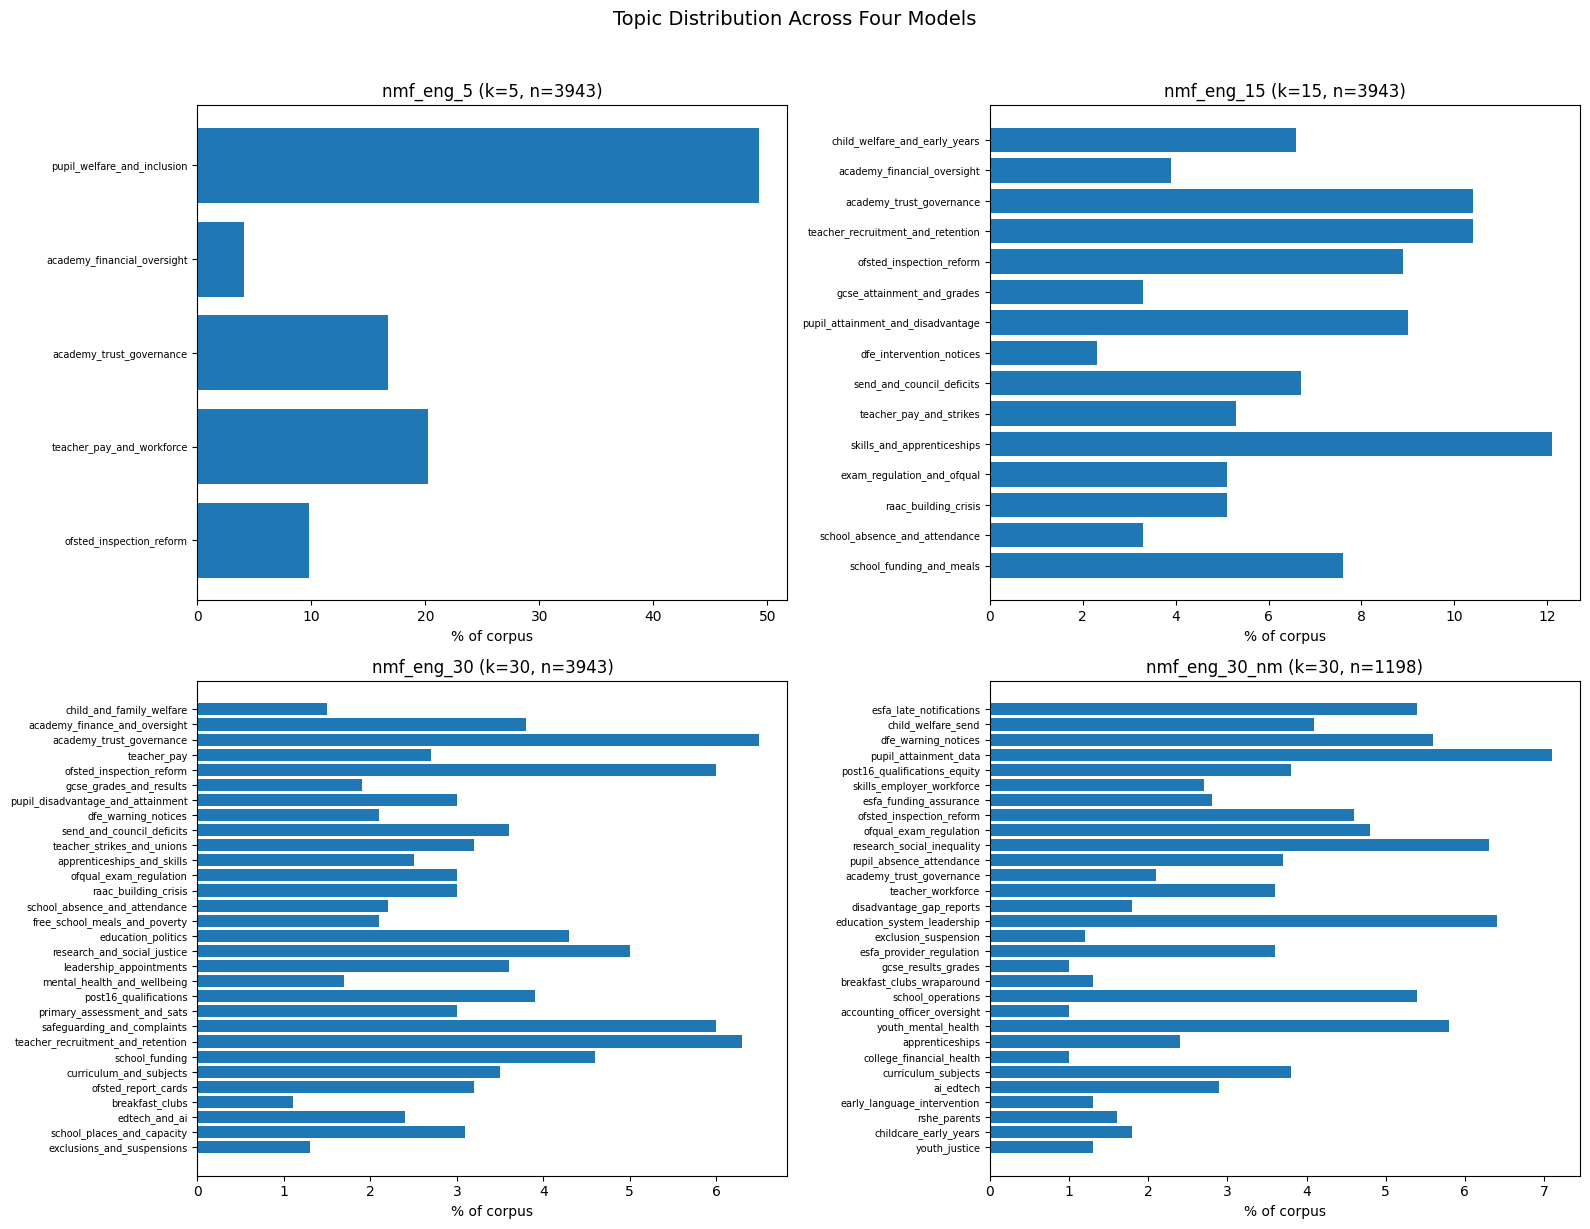

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, model_id in enumerate(["nmf_eng_5", "nmf_eng_15", "nmf_eng_30", "nmf_eng_30_nm"]):
    ax = axes[idx // 2][idx % 2]
    model_df = df[df["model_id"] == model_id].sort_values("topic_num")
    
    ax.barh(range(len(model_df)), model_df["pct"])
    ax.set_yticks(range(len(model_df)))
    ax.set_yticklabels(model_df["name"], fontsize=7)
    ax.set_xlabel("% of corpus")
    ax.set_title(f"{model_id} (k={model_df['k'].iloc[0]}, n={model_df['n_articles'].iloc[0]})")
    ax.invert_yaxis()

plt.suptitle("Topic Distribution Across Four Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/4model_topic_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

#### At k=5, one topic holds 49% of the corpus — a false hierarchy that compresses eight distinct policy areas into one label. By k=30, the largest topic is 6.5–7.1% and the distribution is even. The statistical shape (largest/smallest, spread) is similar between k=30 full and k=30 NM — but which topic is largest changes entirely: academy_trust_governance vs pupil_attainment_data. Same statistical properties, different substantive content.

## 3. Source concentration comparison

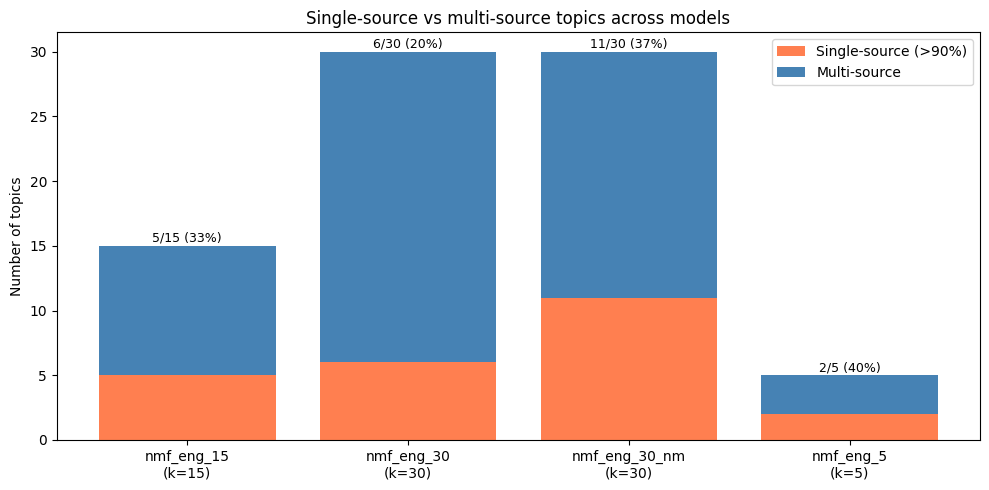

In [5]:
source_summary = df.groupby("model_id").agg(
    single_source=("single_source", "sum"),
    total=("topic_num", "count"),
).reset_index()
source_summary["multi_source"] = source_summary["total"] - source_summary["single_source"]

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(source_summary))
ax.bar(x, source_summary["single_source"], label="Single-source (>90%)", color="coral")
ax.bar(x, source_summary["multi_source"], bottom=source_summary["single_source"], label="Multi-source", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels([f"{r['model_id']}\n(k={models[r['model_id']]['n_topics']})" for _, r in source_summary.iterrows()])
ax.set_ylabel("Number of topics")
ax.set_title("Single-source vs multi-source topics across models")
ax.legend()

for i, row in source_summary.iterrows():
    ax.text(i, row["total"] + 0.3, f"{int(row['single_source'])}/{row['total']} ({row['single_source']/row['total']*100:.0f}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/4model_source_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Source breakdown per topic per model
for model_id in ["nmf_eng_5", "nmf_eng_15", "nmf_eng_30", "nmf_eng_30_nm"]:
    model_df = df[df["model_id"] == model_id].sort_values("topic_num")
    print(f"\n{'='*80}")
    print(f"  {model_id} (k={model_df['k'].iloc[0]})")
    print(f"{'='*80}")
    for _, t in model_df.iterrows():
        marker = " <<<" if t["single_source"] else ""
        print(f"  {t['name']:<45} {t['top_source']:<15} {t['top_source_pct']:.0%}{marker}")


  nmf_eng_5 (k=5)
  pupil_welfare_and_inclusion                   schoolsweek     61%
  academy_financial_oversight                   gov             99% <<<
  academy_trust_governance                      schoolsweek     79%
  teacher_pay_and_workforce                     schoolsweek     92% <<<
  ofsted_inspection_reform                      schoolsweek     81%

  nmf_eng_15 (k=15)
  child_welfare_and_early_years                 schoolsweek     58%
  academy_financial_oversight                   gov             99% <<<
  academy_trust_governance                      schoolsweek     91% <<<
  teacher_recruitment_and_retention             schoolsweek     89%
  ofsted_inspection_reform                      schoolsweek     82%
  gcse_attainment_and_grades                    schoolsweek     49%
  pupil_attainment_and_disadvantage             schoolsweek     61%
  dfe_intervention_notices                      gov             90%
  send_and_council_deficits                     schoolsweek 

#### The single-source ratio drops from 40% (k=5) to 20% (k=30 full) as more topics create room for mixed-source topics. But it jumps back to 37% at k=30 NM — without Schools Week's generalist coverage mixing into everything, specialist sources each dominate their own topics. Schools Week artificially lowered source concentration by appearing everywhere. Remove it and the true institutional segmentation becomes visible.



## 4. Dominant weight comparison — model confidence across k

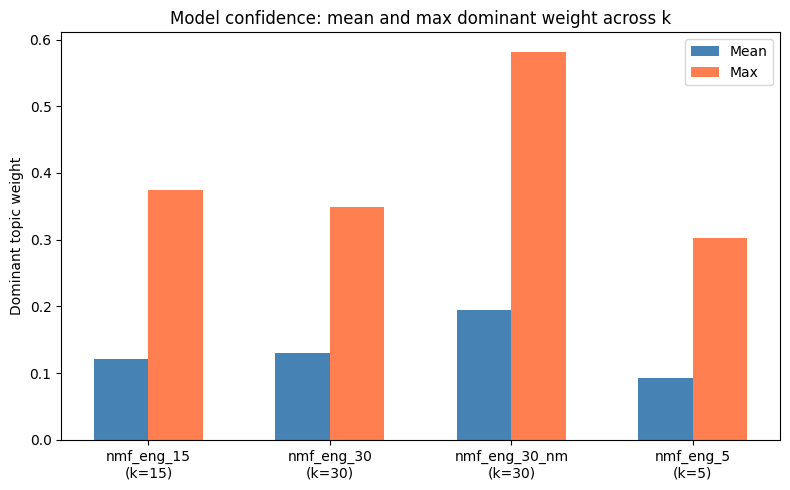

     model_id  k  mean_weight  max_weight
   nmf_eng_15 15       0.1216      0.3741
   nmf_eng_30 30       0.1299      0.3492
nmf_eng_30_nm 30       0.1946      0.5817
    nmf_eng_5  5       0.0922      0.3029


In [7]:
# Dominant weight comparison from the master DataFrame
weight_df = df.groupby("model_id").agg(
    k=("k", "first"),
    mean_weight=("mean_dominant_weight", "first"),
    max_weight=("max_dominant_weight", "first"),
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(weight_df))
ax.bar([i - 0.15 for i in x], weight_df["mean_weight"], width=0.3, label="Mean", color="steelblue")
ax.bar([i + 0.15 for i in x], weight_df["max_weight"], width=0.3, label="Max", color="coral")
ax.set_xticks(x)
ax.set_xticklabels([f"{r['model_id']}\n(k={r['k']})" for _, r in weight_df.iterrows()])
ax.set_ylabel("Dominant topic weight")
ax.set_title("Model confidence: mean and max dominant weight across k")
ax.legend()
plt.tight_layout()
plt.savefig("/workspaces/AM1_topic_modelling/data/evaluation_outputs/4model_weights.png", dpi=150, bbox_inches="tight")
plt.show()

print(weight_df.to_string(index=False))

#### Mean dominant weight of 0.09–0.19 means the "dominant topic" label on any article represents only 9–19% of its content. The other 81–91% is spread across other topics. The dashboard shows one label per article as if it were a fact — but the model is uncertain about almost everything. The NM model's higher confidence (0.19) reflects specialist sources writing about one thing; the full model's lower confidence (0.13) reflects journalism covering multiple policy areas per article.



## 5. What changes between k=5 and k=30? — Topic splitting

In [8]:
k5_topics = {t["name"]: t for t in models.get("nmf_eng_5", {}).get("topics", [])}
k15_topics = {t["name"]: t for t in models.get("nmf_eng_15", {}).get("topics", [])}
k30_topics = {t["name"]: t for t in models.get("nmf_eng_30", {}).get("topics", [])}

if k5_topics:
    print("How k=5 topics split at k=15 and k=30:")
    print("=" * 80)
    
    splits = {
        "pupil_welfare_and_inclusion (k=5, 49.3%)": {
            "k=15": ["child_welfare_and_early_years", "pupil_attainment_and_disadvantage", 
                     "send_and_council_deficits", "school_absence_and_attendance"],
            "k=30": ["child_and_family_welfare", "pupil_disadvantage_and_attainment",
                     "send_and_council_deficits", "school_absence_and_attendance",
                     "free_school_meals_and_poverty", "mental_health_and_wellbeing",
                     "exclusions_and_suspensions", "primary_assessment_and_sats"],
        },
        "teacher_pay_and_workforce (k=5)": {
            "k=15": ["teacher_recruitment_and_retention", "teacher_pay_and_strikes"],
            "k=30": ["teacher_pay", "teacher_strikes_and_unions", "teacher_recruitment_and_retention"],
        },
        "academy_financial_oversight (k=5)": {
            "k=15": ["academy_financial_oversight"],
            "k=30": ["academy_finance_and_oversight"],
        },
        "academy_trust_governance (k=5)": {
            "k=15": ["academy_trust_governance", "dfe_intervention_notices"],
            "k=30": ["academy_trust_governance", "dfe_warning_notices"],
        },
        "ofsted_inspection_reform (k=5)": {
            "k=15": ["ofsted_inspection_reform"],
            "k=30": ["ofsted_inspection_reform", "ofsted_report_cards"],
        },
    }
    
    for parent, children in splits.items():
        print(f"\n{parent}")
        for k_level, topics in children.items():
            print(f"  {k_level}: {', '.join(topics)}")

How k=5 topics split at k=15 and k=30:

pupil_welfare_and_inclusion (k=5, 49.3%)
  k=15: child_welfare_and_early_years, pupil_attainment_and_disadvantage, send_and_council_deficits, school_absence_and_attendance
  k=30: child_and_family_welfare, pupil_disadvantage_and_attainment, send_and_council_deficits, school_absence_and_attendance, free_school_meals_and_poverty, mental_health_and_wellbeing, exclusions_and_suspensions, primary_assessment_and_sats

teacher_pay_and_workforce (k=5)
  k=15: teacher_recruitment_and_retention, teacher_pay_and_strikes
  k=30: teacher_pay, teacher_strikes_and_unions, teacher_recruitment_and_retention

academy_financial_oversight (k=5)
  k=15: academy_financial_oversight
  k=30: academy_finance_and_oversight

academy_trust_governance (k=5)
  k=15: academy_trust_governance, dfe_intervention_notices
  k=30: academy_trust_governance, dfe_warning_notices

ofsted_inspection_reform (k=5)
  k=15: ofsted_inspection_reform
  k=30: ofsted_inspection_reform, ofsted_re

## 6. k=30 vs k=30 no media — what changes when SchoolsWeek is removed?

In [9]:
full_df = df[df["model_id"] == "nmf_eng_30"]
nm_df = df[df["model_id"] == "nmf_eng_30_nm"]

if len(full_df) > 0 and len(nm_df) > 0:
    print(f"Full corpus: {full_df['n_articles'].iloc[0]} articles, {len(full_df)} topics")
    print(f"No media:    {nm_df['n_articles'].iloc[0]} articles, {len(nm_df)} topics")
    
    full_names = set(full_df["name"])
    nm_names = set(nm_df["name"])
    
    print(f"\nTopics only in full corpus: {full_names - nm_names}")
    print(f"Topics only in no-media:    {nm_names - full_names}")
    print(f"Shared topic names:         {len(full_names & nm_names)}")
    
    print(f"\nNo-media topics (sorted by share):")
    for _, t in nm_df.sort_values("pct", ascending=False).iterrows():
        print(f"  {t['name']:<45} {t['count']:>4} ({t['pct']}%)  top: {t['top_source']} {t['top_source_pct']:.0%}")
else:
    print("nmf_eng_30_nm not loaded — run the no-media notebook first")

Full corpus: 3943 articles, 30 topics
No media:    1198 articles, 30 topics

Topics only in full corpus: {'breakfast_clubs', 'free_school_meals_and_poverty', 'school_places_and_capacity', 'academy_finance_and_oversight', 'apprenticeships_and_skills', 'post16_qualifications', 'teacher_recruitment_and_retention', 'teacher_pay', 'send_and_council_deficits', 'curriculum_and_subjects', 'ofsted_report_cards', 'research_and_social_justice', 'raac_building_crisis', 'school_absence_and_attendance', 'exclusions_and_suspensions', 'mental_health_and_wellbeing', 'leadership_appointments', 'child_and_family_welfare', 'teacher_strikes_and_unions', 'primary_assessment_and_sats', 'gcse_grades_and_results', 'edtech_and_ai', 'school_funding', 'safeguarding_and_complaints', 'pupil_disadvantage_and_attainment', 'education_politics'}
Topics only in no-media:    {'esfa_late_notifications', 'esfa_funding_assurance', 'research_social_inequality', 'teacher_workforce', 'esfa_provider_regulation', 'skills_employe

#### k=30 vs k=30 NM: What Changes When Schools Week Is Removed
Only 4 of 56 unique topic names are shared (Jaccard = 0.07), though some divergence is relabelling not structural change. Genuinely new NM topics: the ESFA regulatory triplet, youth justice, college financial health, early language intervention — all drowned out by Schools Week's volume. Genuinely disappeared: teacher strikes, teacher pay, education politics, RAAC, safeguarding, school funding — all driven by Schools Week's editorial agenda, not shared discourse. Without Schools Week, 18/30 topics have GOV.UK as top source (8 at 90%+). The disappeared topics were not minor policy areas — they disappeared because they were one outlet's coverage. The distinction between "important in the policy landscape" and "present in this corpus" is the specification choice made visible.

## 7. Summary: specification sensitivity across all four models

In [10]:
print("=" * 80)
print("SPECIFICATION SENSITIVITY SUMMARY — FOUR ENGLAND MODELS")
print("=" * 80)

for model_id in ["nmf_eng_5", "nmf_eng_15", "nmf_eng_30", "nmf_eng_30_nm"]:
    model_df = df[df["model_id"] == model_id]
    largest = model_df.loc[model_df["pct"].idxmax()]
    single = int(model_df["single_source"].sum())
    
    print(f"\n{model_id} (k={model_df['k'].iloc[0]}, n={model_df['n_articles'].iloc[0]})")
    print(f"  Stability:        {model_df['stability'].iloc[0]:.4f}")
    print(f"  Mean weight:      {model_df['mean_dominant_weight'].iloc[0]:.4f}")
    print(f"  Largest topic:    {largest['name']} ({largest['pct']}%)")
    print(f"  Single-source:    {single}/{len(model_df)}")

print(f"\n{'='*80}")
print("Key finding: same data, same pipeline, different k → different findings.")
print("Same k, different data (media removed) → different findings.")
print("Standard quality metrics do not flag these differences.")
print(f"{'='*80}")

SPECIFICATION SENSITIVITY SUMMARY — FOUR ENGLAND MODELS

nmf_eng_5 (k=5, n=3943)
  Stability:        1.0000
  Mean weight:      0.0922
  Largest topic:    pupil_welfare_and_inclusion (49.3%)
  Single-source:    2/5

nmf_eng_15 (k=15, n=3943)
  Stability:        1.0000
  Mean weight:      0.1216
  Largest topic:    skills_and_apprenticeships (12.1%)
  Single-source:    5/15

nmf_eng_30 (k=30, n=3943)
  Stability:        0.9663
  Mean weight:      0.1299
  Largest topic:    academy_trust_governance (6.5%)
  Single-source:    6/30

nmf_eng_30_nm (k=30, n=1198)
  Stability:        0.9609
  Mean weight:      0.1946
  Largest topic:    pupil_attainment_data (7.1%)
  Single-source:    11/30

Key finding: same data, same pipeline, different k → different findings.
Same k, different data (media removed) → different findings.
Standard quality metrics do not flag these differences.


## 8. Proxy Concentration — topic distribution evenness

In [11]:
def gini(pcts):
    """Gini coefficient — 0 = perfectly even, 1 = all in one topic."""
    pcts = np.array(pcts)
    pcts = pcts / pcts.sum()
    n = len(pcts)
    sorted_pcts = np.sort(pcts)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * sorted_pcts) - (n + 1) * np.sum(sorted_pcts)) / (n * np.sum(sorted_pcts))

print("PROXY CONCENTRATION")
print("=" * 80)
print("How much of the topic space is dominated by a few topics?\n")

conc_rows = []
for model_id in ["nmf_eng_5", "nmf_eng_15", "nmf_eng_30", "nmf_eng_30_nm"]:
    model_df = df[df["model_id"] == model_id].sort_values("pct", ascending=False)
    top3_pct = model_df["pct"].head(3).sum()
    top5_pct = model_df["pct"].head(5).sum()
    largest = model_df.iloc[0]
    g = gini(model_df["pct"].values)
    
    conc_rows.append({
        "model": model_id,
        "k": model_df["k"].iloc[0],
        "largest_topic": largest["name"],
        "largest_pct": largest["pct"],
        "top3_share": round(top3_pct, 1),
        "top5_share": round(top5_pct, 1),
        "gini": round(g, 3),
    })
    
    print(f"{model_id} (k={model_df['k'].iloc[0]}):")
    print(f"  Largest topic: {largest['name']} at {largest['pct']}%")
    print(f"  Top-3 share:   {top3_pct:.1f}%")
    print(f"  Top-5 share:   {top5_pct:.1f}%")
    print(f"  Gini coeff:    {g:.3f}")
    print()

conc_df = pd.DataFrame(conc_rows)
print(conc_df.to_string(index=False))

PROXY CONCENTRATION
How much of the topic space is dominated by a few topics?

nmf_eng_5 (k=5):
  Largest topic: pupil_welfare_and_inclusion at 49.3%
  Top-3 share:   86.2%
  Top-5 share:   100.1%
  Gini coeff:    0.403

nmf_eng_15 (k=15):
  Largest topic: skills_and_apprenticeships at 12.1%
  Top-3 share:   32.9%
  Top-5 share:   50.8%
  Gini coeff:    0.247

nmf_eng_30 (k=30):
  Largest topic: academy_trust_governance at 6.5%
  Top-3 share:   18.8%
  Top-5 share:   29.8%
  Gini coeff:    0.240

nmf_eng_30_nm (k=30):
  Largest topic: pupil_attainment_data at 7.1%
  Top-3 share:   19.8%
  Top-5 share:   31.2%
  Gini coeff:    0.313

        model  k               largest_topic  largest_pct  top3_share  top5_share  gini
    nmf_eng_5  5 pupil_welfare_and_inclusion         49.3        86.2       100.1 0.403
   nmf_eng_15 15  skills_and_apprenticeships         12.1        32.9        50.8 0.247
   nmf_eng_30 30    academy_trust_governance          6.5        18.8        29.8 0.240
nmf_eng

#### Education Media as Connective Tissue
The proxy concentration analysis reveals something about the education system itself, not just the model. Schools Week covers teacher pay, Ofsted, SEND, academies, RAAC, and safeguarding in one publication — creating a shared discourse space where these issues are discussed together. Remove it and "education policy discourse" fragments into five institutional monologues that never reference each other: government regulation (GOV.UK), data analysis (FFT), academic research (Nuffield), disadvantage reports (EPI), and leadership commentary (FED). The education media doesn't just report on the system — it is the connective tissue between actors who otherwise operate in silos. This finding only becomes visible through specification sensitivity analysis — running one model would never reveal it.

## 9. Specification Sensitivity — how much do findings change under perturbation?

In [12]:
print("SPECIFICATION SENSITIVITY")
print("=" * 80)
print("Topic name overlap between model pairs (Jaccard similarity)\n")

model_ids = ["nmf_eng_5", "nmf_eng_15", "nmf_eng_30", "nmf_eng_30_nm"]
for a, b in combinations(model_ids, 2):
    names_a = set(df[df["model_id"] == a]["name"])
    names_b = set(df[df["model_id"] == b]["name"])
    overlap = names_a & names_b
    jaccard = len(overlap) / len(names_a | names_b) if names_a | names_b else 0
    print(f"{a} vs {b}:")
    print(f"  Shared topics: {len(overlap)}/{len(names_a | names_b)}")
    print(f"  Jaccard similarity: {jaccard:.2f}")
    print(f"  Topics changed: {len(names_a | names_b) - len(overlap)}")
    if overlap:
        print(f"  Shared: {', '.join(sorted(overlap))}")
    print()

# Metric deltas for the source perturbation (k=30 vs k=30 NM)
print("\nMETRIC DELTAS — k=30 vs k=30_nm (source perturbation)")
print("-" * 80)
m30 = df[df["model_id"] == "nmf_eng_30"].iloc[0]
mnm = df[df["model_id"] == "nmf_eng_30_nm"].iloc[0]
print(f"  Stability delta:           {m30['stability'] - mnm['stability']:+.4f}")
print(f"  Mean dominant weight delta: {m30['mean_dominant_weight'] - mnm['mean_dominant_weight']:+.4f}")
print(f"  Reconstruction error delta: {m30['recon_error'] - mnm['recon_error']:+.4f}")

SPECIFICATION SENSITIVITY
Topic name overlap between model pairs (Jaccard similarity)

nmf_eng_5 vs nmf_eng_15:
  Shared topics: 3/17
  Jaccard similarity: 0.18
  Topics changed: 14
  Shared: academy_financial_oversight, academy_trust_governance, ofsted_inspection_reform

nmf_eng_5 vs nmf_eng_30:
  Shared topics: 2/33
  Jaccard similarity: 0.06
  Topics changed: 31
  Shared: academy_trust_governance, ofsted_inspection_reform

nmf_eng_5 vs nmf_eng_30_nm:
  Shared topics: 2/33
  Jaccard similarity: 0.06
  Topics changed: 31
  Shared: academy_trust_governance, ofsted_inspection_reform

nmf_eng_15 vs nmf_eng_30:
  Shared topics: 6/39
  Jaccard similarity: 0.15
  Topics changed: 33
  Shared: academy_trust_governance, ofsted_inspection_reform, raac_building_crisis, school_absence_and_attendance, send_and_council_deficits, teacher_recruitment_and_retention

nmf_eng_15 vs nmf_eng_30_nm:
  Shared topics: 2/43
  Jaccard similarity: 0.05
  Topics changed: 41
  Shared: academy_trust_governance, of

#### Only two topics survive every comparison: academy_trust_governance and ofsted_inspection_reform — anchored to distinct institutions (MATs, Ofsted) with dedicated vocabulary that no perturbation dissolves. Everything else is contingent. No specification choice preserves more than 18% of topic names. The k=30 vs k=30 NM comparison is the sharpest: Jaccard similarity of 0.07 (93% of names change) while stability delta is just +0.005 — diagnostics say the models are identical, topic names say they are not. The policy substance, the debates, the findings a policymaker would act on — all contingent on k and source composition. Only institutionally anchored topics are robust.

### Specification Scoring Summary

Two of three planned specification dimensions are now computable:

**Proxy concentration** measures how evenly the topic space is distributed. At k=5, the top-3 topics hold ~86% of the corpus — the model creates a false hierarchy dominated by a single catch-all. At k=30, the top-3 hold ~20% — a much more even distribution. The Gini coefficient captures this in a single number: higher = more concentrated, lower = more even.

**Specification sensitivity** measures how much findings change under perturbation. The Jaccard similarity between topic name sets quantifies this: k=30 vs k=30 NM has low overlap because removing Schools Week changes ~2/3 of topics. The metric deltas (stability, dominant weights, reconstruction error) show that standard diagnostics remain identical while the substantive findings change — confirming that model evaluation metrics alone cannot detect specification sensitivity.

**Normative divergence** (directional asymmetry across jurisdictions) is deferred — it requires cross-country topic alignment which is not yet implemented under the per-country training design.